#### Logistic regression

> It a classification algorithm..

> Its formula is based on sigmoid function..

> img src= 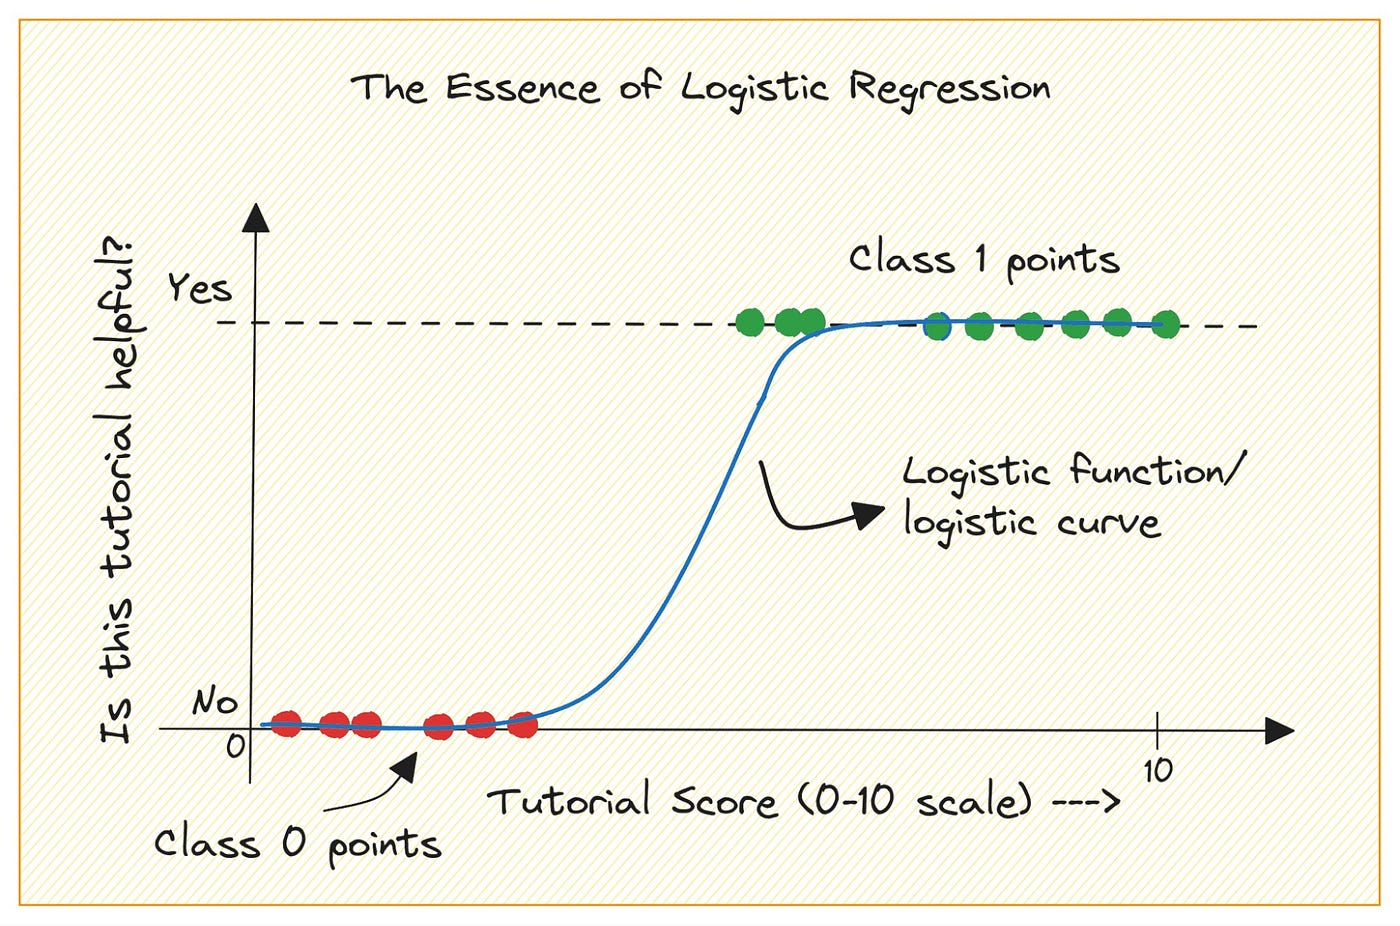

In [75]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [76]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [77]:
columns=["fLength","fWidth","fSize","fConc","fConc1","fAsym"," fM3Long","fM3Trans","fAlpha"," fDist","class"]

In [78]:
df=pd.read_csv("/content/magic04.data",names=columns)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [79]:
df.columns

Index(['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', ' fM3Long',
       'fM3Trans', 'fAlpha', ' fDist', 'class'],
      dtype='object')

In [80]:
df["class"]=(df["class"]=="g").astype(int)

In [81]:
df["class"]

,class
0,1
1,1
2,1
3,1
4,1
...,...
19015,0
19016,0
19017,0
19018,0


In [82]:
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])

/usr/local/lib/python3.13/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [83]:
train=pd.DataFrame(train)
valid=pd.DataFrame(valid)
test=pd.DataFrame(test)

In [93]:
def scale_data(dataframe, oversample=False):
  X = dataframe[dataframe.columns[:-1]].values#input
  y = dataframe[dataframe.columns[-1]].values#output

  scaler = StandardScaler()
  X = scaler.fit_transform(X) # its scaled input

  if oversample:
    ros = RandomOverSampler()
    X, y = ros.fit_resample(X, y)

  data = np.hstack((X, np.reshape(y, (-1, 1))))

  return data, X, y

>>> Standardization and Balancing

In [96]:
train = pd.DataFrame(train)
valid = pd.DataFrame(valid)
test = pd.DataFrame(test)

In [97]:
train, X_train, y_train = scale_data(train, oversample=True)
valid, X_valid, y_valid = scale_data(valid, oversample=False)
test, X_test, y_test = scale_data(test, oversample=False)

In [98]:
### using logistic regression model
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [99]:
pred=model.predict(X_test)

In [100]:
### model evaluation
from sklearn.metrics import classification_report
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

         0.0       0.64      0.77      0.70      1350
         1.0       0.86      0.76      0.81      2454

    accuracy                           0.77      3804
   macro avg       0.75      0.77      0.76      3804
weighted avg       0.78      0.77      0.77      3804

